In [1]:
import sys
from pathlib import Path

scripts_dir = Path.cwd().parent / "scripts"
sys.path.insert(0, str(scripts_dir))

In [2]:
# Path to test .mrxs
path_CMU1 = r"E:\Christine\testdata\CMU-1.mrxs"
path_CMU3 = r"E:\Christine\testdata\CMU-3.mrxs"
zarr_dir = r"E:\Christine\testdata\zarr"
cache_tissue = r"E:\Christine\testdata\cache_tissue_artifact.pkl"
cache_features = r"E:\Christine\testdata\feature_summary.csv"

slides = [path_CMU1, path_CMU3]

In [3]:
from tissue_artifact_segmentation import SegmentMany

segmenter = SegmentMany(slides, cache_tissue, zarr_dir, "tissue", version="default")

C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  fro

Tissue already segmented: tissue_default
Tissue processing complete for E:\Christine\testdata\zarr\CMU-1.zarr
Tissue already segmented: tissue_default
Tissue processing complete for E:\Christine\testdata\zarr\CMU-3.zarr


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\Users\KBHUNI~1\anaconda3\envs\lazyslide_env\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


WSI: E:\Christine\testdata\CMU-3.mrxs
Reader: openslide
Dimensions: 220696×109240 (h×w), 10 Pyramids
Pixel physical size: 0.2325 MPP
SpatialData object, with associated Zarr store: E:\Christine\testdata\zarr\CMU-3.zarr
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 989, 489)
└── Shapes
      ├── 'tiles_224': GeoDataFrame shape: (34417, 3) (2D shapes)
      ├── 'tiles_px512_mpp1.5_overlap0.1': GeoDataFrame shape: (175, 3) (2D shapes)
      └── 'tissue_default': GeoDataFrame shape: (5, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), tiles_224 (Shapes), tiles_px512_mpp1.5_overlap0.1 (Shapes), tissue_default (Shapes)
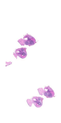

In [4]:
# Visualize Single Slide
import os
from wsidata import open_wsi

zarr_path = os.path.join(zarr_dir, os.path.basename(path_CMU3).replace(".mrxs", ".zarr"))
wsi = open_wsi(path_CMU3, zarr_path)
wsi

In [ ]:
from feature_extraction import ExtractMany

model = "h-optimus-0"
extractor = ExtractMany(slides, cache_features, zarr_dir, model, remove_artifacts = False)

Extracting features ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   2% --:--

In [ ]:
# Generate df that resembles pathology df in 100k project
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "filename": [str(x) for x in slides],
    "class":  np.random.randint(0, 2, size=len(slides))
}).reset_index(drop=True)